## Codigo para pruebas de solo encoder para prediccion de elo

In [67]:
import os
import io
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm  # Usa tqdm normal si ejecutas desde script .py, o tqdm.notebook si usas Jupyter
import chess
import chess.pgn
import joblib
from sklearn.metrics import accuracy_score
# Imports de PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix
import seaborn as sns
import torch.nn.functional as F

# --- FIJAR SEMILLAS PARA REPRODUCIBILIDAD EN PYTORCH ---
SEED = 37

random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # Para cuando usas múltiples GPUs
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

plt.ion()

In [68]:
# Verificación de aceleración por GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo activo: {device}")
if device.type == "cuda":
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")

Dispositivo activo: cuda
GPU detectada: NVIDIA GeForce RTX 4060 Laptop GPU


In [112]:
# datos tomados del train
ELO_MIN = 1000 
ELO_MAX = 3390
ELO_MEAN = 2028.3
ELO_STD = 593.4
ELO_MEDIAN = 2028.0
ELO_Q1 = 1514.0
ELO_Q3 = 2538.0 
ELO_IQR = ELO_Q3 - ELO_Q1
MEDIA_DESP_CORTE = 2906.705

In [82]:
class EMD(nn.Module): # Earth Mover's Distance
    def __init__(self, num_clases=8):
        super(EMD, self).__init__()
        self.num_clases = num_clases

    def forward(self, logits, targets):
        """
        logits: Tensor de forma [batch_size, num_clases] (salida cruda de la red, sin Softmax)
        targets: Tensor de forma [batch_size] con las etiquetas reales (enteros 0 a 7)
        """
        # 1. Convertir los logits a probabilidades normales
        probs = F.softmax(logits, dim=1)
        
        # 2. Calcular la Probabilidad Acumulada de las predicciones
        # Ej: [0.1, 0.2, 0.7] -> [0.1, 0.3, 1.0]
        cum_probs = torch.cumsum(probs, dim=1)
        
        # 3. Crear el target one-hot y calcular su Probabilidad Acumulada
        # Ej target 2: [0, 0, 1, 0, 0, 0, 0, 0] -> [0, 0, 1, 1, 1, 1, 1, 1]
        one_hot_targets = F.one_hot(targets, num_classes=self.num_clases).float()
        cum_targets = torch.cumsum(one_hot_targets, dim=1)
        
        # 4. Error Cuadrático Medio (MSE) entre las distribuciones acumuladas
        loss = torch.mean((cum_probs - cum_targets) ** 2)
        
        return loss

In [143]:
class DistanceWeightedCE(nn.Module):
    def __init__(self, num_clases=8, penalty_type='l2'):
        super().__init__()
        self.num_clases = num_clases
        
        # Generar la grilla de índices
        idx = torch.arange(num_clases, dtype=torch.float32)
        
        if penalty_type == 'l2':
            # Penalización cuadrática (castiga severamente los extremos)
            self.cost_matrix = (idx.unsqueeze(0) - idx.unsqueeze(1)) ** 2
        else:
            # Penalización lineal estricta (|i - j|)
            self.cost_matrix = torch.abs(idx.unsqueeze(0) - idx.unsqueeze(1))
            
        # Normalizar la matriz de costos para no explotar los gradientes
        self.cost_matrix = self.cost_matrix / self.cost_matrix.max()

    def forward(self, logits, targets):
        # Mover la matriz de costos al mismo dispositivo que los tensores (GPU/CPU)
        self.cost_matrix = self.cost_matrix.to(logits.device)
        
        # 1. Obtener las probabilidades predichas (Softmax)
        probs = F.softmax(logits, dim=1)
        
        # 2. Seleccionar la fila de costos correspondiente al target real de cada ejemplo
        # Si el target es 3, extrae los costos [9, 4, 1, 0, 1, 4, 9, 16] (escalados)
        batch_costs = self.cost_matrix[targets]
        
        # 3. Multiplicar las probabilidades por los costos y sumar
        # La red minimiza esto reduciendo la probabilidad en las celdas de alto costo
        loss = torch.mean(torch.sum(batch_costs * probs, dim=1))
        
        return loss

In [144]:
def gaussian_soft_targets(targets, num_clases=8, sigma=1.0):
    """
    Convierte el target escalar en una distribución gaussiana.
    sigma controla la tolerancia: un sigma mayor achata la curva, 
    tolerando más el error en bins adyacentes.
    """
    # Crear un tensor con los índices de las clases [0, 1, ..., num_clases-1]
    clases = torch.arange(num_clases, dtype=torch.float32, device=targets.device)
    
    # Calcular la distancia al cuadrado desde cada clase al target real
    # Expandimos dimensiones para operar sobre todo el batch a la vez
    distancias_cuadradas = (clases.unsqueeze(0) - targets.unsqueeze(1).float()) ** 2
    
    # Aplicar la función de densidad gaussiana (sin la constante de normalización inicial)
    soft_targets = torch.exp(-distancias_cuadradas / (2 * sigma ** 2))
    
    # Normalizar para que la suma de probabilidades en cada fila sea exactamente 1
    soft_targets = soft_targets / soft_targets.sum(dim=1, keepdim=True)
    
    return soft_targets


In [145]:
class ChessClassificationDataset(Dataset):
    def __init__(self, npz_path, plies_a_usar=None, flatten=True, return_ids=False,num_clases = 18, divisor = 100):
        datos = np.load(npz_path)

        X_completo = datos['X']
        plies_guardados = datos['plies_guardados'].tolist()
        self.return_ids = return_ids

        if plies_a_usar is None:
            indices = list(range(len(plies_guardados)))
        else:
            indices = [plies_guardados.index(p) for p in plies_a_usar]
            
        X_filtrado = X_completo[:, indices, :]
        
        if flatten:
            X_filtrado = X_filtrado.reshape(X_filtrado.shape[0], -1)
            
        # Guardamos en RAM como int8
        self.X = torch.tensor(X_filtrado, dtype=torch.int8)
        self.game_idx = datos['game_idx']
        
        # --- LÓGICA EXCLUSIVA DE CLASIFICACIÓN ---
        # 1. Cargamos el Elo crudo
        y_raw = datos['y_raw']
        
        # 2. Limitamos los extremos para tener exactamente 18 clases (0 a 17)
        y_clipped = np.clip(y_raw, 1000, 1000+(num_clases-1)*divisor)
        
        y_clases = (y_clipped - 1000) // divisor
        
        self.y = torch.tensor(y_clases, dtype=torch.long)
        
        self.input_dim = self.X.shape[1] if flatten else self.X.shape[2]

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x_tensor = self.X[idx].to(torch.float32)
        y_tensor = self.y[idx]

        if self.return_ids:
            idx_partida = self.game_idx[idx]
            return x_tensor, y_tensor, idx_partida
        else:
            return x_tensor, y_tensor

In [174]:
plies = [15, 19,23,27]   
ply = plies
flatten = 0
num_clases = 8
divisor = 250
crit = "weighted" # earth, gauss, weighted, cross
print("Cargando datasets a la memoria...")
ply_for_data = 51
train_ds = ChessClassificationDataset(f"../data/generado/only_enc/train_{ply_for_data}.npz", plies_a_usar=plies, flatten=flatten,num_clases=num_clases, divisor = divisor)
val_ds = ChessClassificationDataset(f"../data/generado/only_enc/val_{ply_for_data}.npz", plies_a_usar=plies, flatten=flatten,num_clases=num_clases, divisor = divisor)
test_ds = ChessClassificationDataset(f"../data/generado/only_enc/test_{ply_for_data}.npz", plies_a_usar=plies, flatten=flatten,num_clases=num_clases,  divisor = divisor, return_ids=True)

# El DataLoader se encarga de crear los batches y hacer el shuffle usando C++ internamente
train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=512, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=512, shuffle=False)

Cargando datasets a la memoria...


In [175]:
print("TRAIN")
print(train_ds.y.bincount())

print("\nVAL")
print(val_ds.y.bincount())

print("\nTEST")
print(test_ds.y.bincount())


TRAIN
tensor([34470, 35530, 34894, 35106, 35557, 34443, 36336, 41777])

VAL
tensor([7431, 7569, 7590, 7410, 7562, 7438, 7379, 3573])

TEST
tensor([7408, 7592, 7487, 7513, 7603, 7397, 7490, 4643])


In [176]:
encoder_salida = f"../data/encoders/only_enc/prueba.pth"
#encoder_salida = f"../data/encoders/only_enc/pesos_norm_{norm}_ply_{ply}_loss_{crit}.pth"
pred_salida = f"../data/predict/prueba.npy"
#pred_salida = f"../data/predict/{crit}_{norm}_{ply[0]}.npy"

In [177]:
"""# Encoder para una posición

class ChessEncoder(nn.Module):
    def __init__(self, input_dim,num_clases):
        super(ChessEncoder, self).__init__()
        self.red = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_clases)
        )

    def forward(self, x):
        return self.red(x)"""

'# Encoder para una posición\n\nclass ChessEncoder(nn.Module):\n    def __init__(self, input_dim,num_clases):\n        super(ChessEncoder, self).__init__()\n        self.red = nn.Sequential(\n            nn.Linear(input_dim, 512),\n            nn.ReLU(),\n            nn.Dropout(p=0.4),\n            nn.Linear(512, 256),\n            nn.ReLU(),\n            nn.Dropout(p=0.3),\n            nn.Linear(256, 128),\n            nn.ReLU(),\n            nn.Dropout(p=0.2),\n            nn.Linear(128, 64),\n            nn.ReLU(),\n            nn.Linear(64, num_clases)\n        )\n\n    def forward(self, x):\n        return self.red(x)'

In [178]:
"""
class ChessEncoder(nn.Module):
    def __init__(self, input_dim, num_clases):
        super(ChessEncoder, self).__init__()
        
        # Arquitectura más compacta: previene el colapso de VRAM y mejora la generalización
        self.red = nn.Sequential(
            # Capa 1: Compresión inicial. Evitamos saltar a 4096 para controlar los pesos.
            nn.Linear(input_dim, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(),
            nn.Dropout(p=0.4), # Dropout ligeramente mayor en la entrada para forzar robustez
            
            # Capa 2
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            
            # Capa 3
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            
            # Capa 4 (Corregido de 258 a 256 por alineación de memoria en GPU)
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.2), # Reducimos el dropout a medida que se condensa la información
            
            # Capa 5: Transición final sin dropout
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            
            # Salida: 1 valor continuo (Elo)
            nn.Linear(64, num_clases) 
        )

    def forward(self, x):
        # x debe venir aplanado desde el DataLoader: (Batch, 832 * cant_plies)
        return self.red(x)"""

'\nclass ChessEncoder(nn.Module):\n    def __init__(self, input_dim, num_clases):\n        super(ChessEncoder, self).__init__()\n\n        # Arquitectura más compacta: previene el colapso de VRAM y mejora la generalización\n        self.red = nn.Sequential(\n            # Capa 1: Compresión inicial. Evitamos saltar a 4096 para controlar los pesos.\n            nn.Linear(input_dim, 2048),\n            nn.BatchNorm1d(2048),\n            nn.ReLU(),\n            nn.Dropout(p=0.4), # Dropout ligeramente mayor en la entrada para forzar robustez\n\n            # Capa 2\n            nn.Linear(2048, 1024),\n            nn.BatchNorm1d(1024),\n            nn.ReLU(),\n            nn.Dropout(p=0.3),\n\n            # Capa 3\n            nn.Linear(1024, 512),\n            nn.BatchNorm1d(512),\n            nn.ReLU(),\n            nn.Dropout(p=0.3),\n\n            # Capa 4 (Corregido de 258 a 256 por alineación de memoria en GPU)\n            nn.Linear(512, 256),\n            nn.BatchNorm1d(256),\n    

In [179]:
# Encoder para multiples plies, comparten encoder al principio
class ChessEncoder(nn.Module):
    def __init__(self, input_dim, num_clases, embed_dim=256):
        super(ChessEncoder, self).__init__()
        self.red = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            nn.Linear(512, embed_dim),
            nn.BatchNorm1d(embed_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.red(x)  # (batch, embed_dim), ya NO es el Elo


class EloPredictor(nn.Module):
    def __init__(self, input_dim,num_clases, embed_dim=256, n_plies=2):
        super(EloPredictor, self).__init__()
        self.encoder = ChessEncoder(input_dim, embed_dim)  # una sola instancia
        self.n_plies = n_plies
        self.head = nn.Sequential(
            nn.Linear(embed_dim * n_plies, 512), #
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.2),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, num_clases),
        )

    def forward(self, plies):
        # plies: lista de tensores (batch, input_dim), uno por cada ply
        embeddings = [self.encoder(plies[:, i, :]) for i in range(self.n_plies)]
        combined = torch.cat(embeddings, dim=1)
        return self.head(combined)

In [180]:
if flatten:
    modelo = ChessEncoder(input_dim=train_ds.X.shape[1],num_clases=num_clases).to(device)
else: 
    modelo = EloPredictor(input_dim=train_ds.X.shape[2],n_plies=len(plies),num_clases=num_clases).to(device)

if len(plies)>1:
    optimizador = torch.optim.AdamW(modelo.parameters(), lr=3e-4, weight_decay=1e-4)
else:
    optimizador = torch.optim.AdamW(modelo.parameters(), lr=7e-4)
if crit == "cross":   
    criterio = nn.CrossEntropyLoss(label_smoothing=0.1)
elif crit == "earth": # earth, gauss, weighted, cross
    criterio = EMD(num_clases=num_clases)
elif crit == "gauss":
    criterio = nn.CrossEntropyLoss()
elif crit == "weighted":
    criterio = DistanceWeightedCE(num_clases=num_clases)


In [181]:
# --- BUCLE DE ENTRENAMIENTO ---
epocas = 50
paciencia = 5
mejor_val_loss = float('inf')
epocas_sin_mejora = 0


for epoca in range(epocas):
    # Fase de Entrenamiento
    modelo.train()
    train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizador.zero_grad()           # 1. Limpiar gradientes viejos
        predicciones = modelo(batch_X)    # 2. Predecir
        if crit == "gauss":
            targets_suaves = gaussian_soft_targets(batch_y, num_clases=num_clases, sigma=1.0)
            loss = criterio(predicciones, targets_suaves) # 3. Calcular el error
        else:
            loss = criterio(predicciones, batch_y)
        loss.backward()                   # 4. Propagar el error hacia atrás (Backprop)
        optimizador.step()                # 5. Actualizar los pesos
        
        train_loss += loss.item() * batch_X.size(0)
    
    # Fase de Validación
    modelo.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            predicciones = modelo(batch_X)
            loss = criterio(predicciones, batch_y)
            val_loss += loss.item() * batch_X.size(0)
            
    # Promedios de la época
    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)
    print(f"Época {epoca+1}/{epocas} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    # --- EARLY STOPPING ---
    if val_loss < mejor_val_loss:
        mejor_val_loss = val_loss
        epocas_sin_mejora = 0
        
        # 1. Empaquetamos los pesos y los metadatos del experimento
        checkpoint = {
            'input_dim': train_ds.input_dim,
            'arquitectura': 'Dense_512_256_128_32',
            'epoca_optima': epoca + 1,
            'estado_pesos': modelo.state_dict()
        }
        
        # 2. Guardo el archivo
        torch.save(checkpoint, encoder_salida) 
        
    else:
        epocas_sin_mejora += 1
        if epocas_sin_mejora >= paciencia:
            print(f"\nEarly stopping activado. El modelo no mejoró en {paciencia} épocas.")
            print(f"Recuperando los mejores pesos de la época {epoca + 1 - paciencia}...")
            
            # 3. Cargamos el archivo completo a la RAM
            checkpoint_recuperado = torch.load(encoder_salida)
            
            modelo.load_state_dict(checkpoint_recuperado['estado_pesos'])

            break

Época 1/50 | Train Loss: 0.0939 | Val Loss: 0.0664
Época 2/50 | Train Loss: 0.0683 | Val Loss: 0.0643
Época 3/50 | Train Loss: 0.0658 | Val Loss: 0.0644
Época 4/50 | Train Loss: 0.0643 | Val Loss: 0.0634
Época 5/50 | Train Loss: 0.0636 | Val Loss: 0.0644
Época 6/50 | Train Loss: 0.0627 | Val Loss: 0.0638
Época 7/50 | Train Loss: 0.0621 | Val Loss: 0.0628
Época 8/50 | Train Loss: 0.0618 | Val Loss: 0.0651
Época 9/50 | Train Loss: 0.0611 | Val Loss: 0.0639
Época 10/50 | Train Loss: 0.0607 | Val Loss: 0.0618
Época 11/50 | Train Loss: 0.0604 | Val Loss: 0.0638
Época 12/50 | Train Loss: 0.0599 | Val Loss: 0.0627
Época 13/50 | Train Loss: 0.0595 | Val Loss: 0.0646
Época 14/50 | Train Loss: 0.0592 | Val Loss: 0.0630
Época 15/50 | Train Loss: 0.0591 | Val Loss: 0.0639

Early stopping activado. El modelo no mejoró en 5 épocas.
Recuperando los mejores pesos de la época 10...


C:\Users\agust\AppData\Local\Temp\ipykernel_37224\1394105306.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_recuperado = torch.load(encoder_salida)


In [182]:
modelo.eval() # Modo evaluación

centros = torch.tensor(
    [1125, 1375, 1625, 1875, 2125, 2375, 2625, MEDIA_DESP_CORTE],
    device=device,
    dtype=torch.float32
)

y_true_list = []
y_pred_list = []
lista_indices_pgn = []
suma_probs = torch.zeros(num_clases, device=device)
n = 0
confianzas = []
regresion = []
print("Calculando predicciones de clasificación en el Test set...")
with torch.no_grad():
    for batch_X, batch_y, batch_idx in test_loader:
        batch_X = batch_X.to(device)

        predicciones_logits = modelo(batch_X)
        
        probs = torch.softmax(predicciones_logits, dim=1)
        confianza = probs.max(dim=1).values
        confianzas.extend(confianza.cpu().numpy())
        regresion.extend((probs * centros).sum(dim=1).cpu().numpy())
        clases_predichas = torch.argmax(predicciones_logits, dim=1)
        probs = torch.softmax(predicciones_logits, dim=1)
        suma_probs += probs.sum(dim=0)
        n += batch_X.size(0)

        y_pred_list.extend(clases_predichas.cpu().numpy())
        y_true_list.extend(batch_y.numpy().flatten()) # batch_y ya es el índice real
        lista_indices_pgn.extend(batch_idx.numpy())

y_true_clases = np.array(y_true_list)
y_pred_clases = np.array(y_pred_list)

# --- MÉTRICAS DE CLASIFICACIÓN ---
acc_exacto = accuracy_score(y_true_clases, y_pred_clases)

# Precisión con margen (Acierto si le erró por 1 categoría o menos)
distancia = np.abs(y_true_clases - y_pred_clases)
acc_margen_1 = np.mean(distancia <= 1)
confianzas = np.array(confianzas)
print("plies:",plies,"Loss",crit)
print(f"Accuracy Exacto (mismo bin): {acc_exacto * 100:.2f}%")
print(f"Accuracy con margen de ±1 bin (±{divisor} Elo): {acc_margen_1 * 100:.2f}%")
print("Confianza media:", confianzas.mean())
# --- CONVERSIÓN A ELO PARA GUARDAR ---

y_pred_elo_base = (y_pred_clases * divisor) + 1000
np.save(pred_salida, y_pred_elo_base)

probs_promedio = suma_probs / n

print(probs_promedio.cpu())


Calculando predicciones de clasificación en el Test set...
plies: [15, 19, 23, 27] Loss weighted
Accuracy Exacto (mismo bin): 21.66%
Accuracy con margen de ±1 bin (±250 Elo): 60.30%
Confianza media: 0.97220916
tensor([8.4407e-06, 2.0354e-05, 3.1735e-01, 1.4444e-01, 1.8705e-01, 2.0544e-01,
        1.4568e-01, 1.0686e-05])


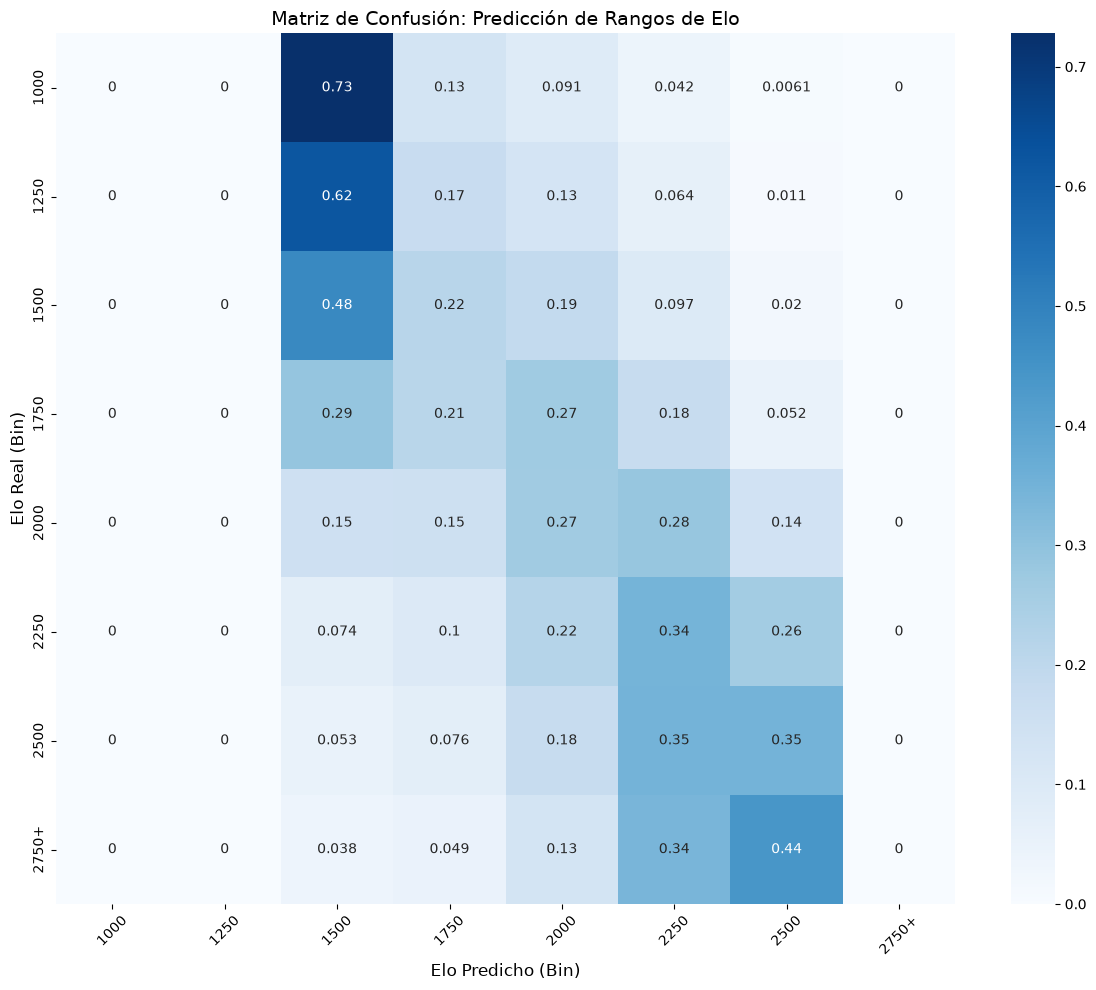

In [183]:
# 1. Generar los nombres de los Bins para los ejes
etiquetas_elo = [f"{1000 + i*divisor}" for i in range(num_clases)]
etiquetas_elo[-1] = f"{1000+(num_clases-1)*divisor}+"
# 2. Calcular la matriz
cm = confusion_matrix(y_true_clases, y_pred_clases)

# 3. Opcional pero recomendado para tesis: Normalizar la matriz por filas 
# (Muestra porcentajes en lugar de conteos absolutos, útil si las clases están desbalanceadas)
cm_porcentual = confusion_matrix(y_true_clases, y_pred_clases, normalize='true')

# 4. Dibujar el mapa de calor (Heatmap)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_porcentual, 
            annot=True,
            cmap="Blues", 
            xticklabels=etiquetas_elo, 
            yticklabels=etiquetas_elo)

plt.xlabel("Elo Predicho (Bin)", fontsize=12)
plt.ylabel("Elo Real (Bin)", fontsize=12)
plt.title("Matriz de Confusión: Predicción de Rangos de Elo", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Convertir el clasificador en un "regresor"

In [184]:
"""
#codigo para obtener el promedio de los que tienen mas que 2

y_raw_train = np.load(f"../data/generado/only_enc/train_{51}.npz")["y_raw"]

media_elo_plus_train = y_raw_train[y_raw_train >= divisor].mean()

print(media_elo_plus_train)
"""

'\n#codigo para obtener el promedio de los que tienen mas que 2\n\ny_raw_train = np.load(f"../data/generado/only_enc/train_{51}.npz")["y_raw"]\n\nmedia_elo_plus_train = y_raw_train[y_raw_train >= divisor].mean()\n\nprint(media_elo_plus_train)\n'

In [185]:
y_raw_test = np.load(f"../data/generado/only_enc/test_{51}.npz")["y_raw"]


In [186]:
errores_absolutos = np.abs(y_raw_test - regresion)
errores_cuadraticos = (y_raw_test - regresion) ** 2

# 2. Calculamos las métricas globales
mae = np.mean(errores_absolutos)
mse = np.mean(errores_cuadraticos)
rmse = np.sqrt(mse)

# 3. Métricas extra útiles para la tesis
error_mediano = np.median(errores_absolutos)
max_error = np.max(errores_absolutos)
print(f"Criterio: {crit}     Ply: {plies}")
print(f"MAE (Error Absoluto Medio):   {mae:.1f} puntos de Elo")
print(f"Mediana del Error:            {error_mediano:.1f} puntos de Elo")
print(f"RMSE (Raíz Error Cuadrático): {rmse:.1f} puntos de Elo")
print(f"Peor equivocación del modelo: {max_error:.1f} puntos de Elo")

Criterio: weighted     Ply: [15, 19, 23, 27]
MAE (Error Absoluto Medio):   346.7 puntos de Elo
Mediana del Error:            299.0 puntos de Elo
RMSE (Raíz Error Cuadrático): 432.3 puntos de Elo
Peor equivocación del modelo: 1592.5 puntos de Elo


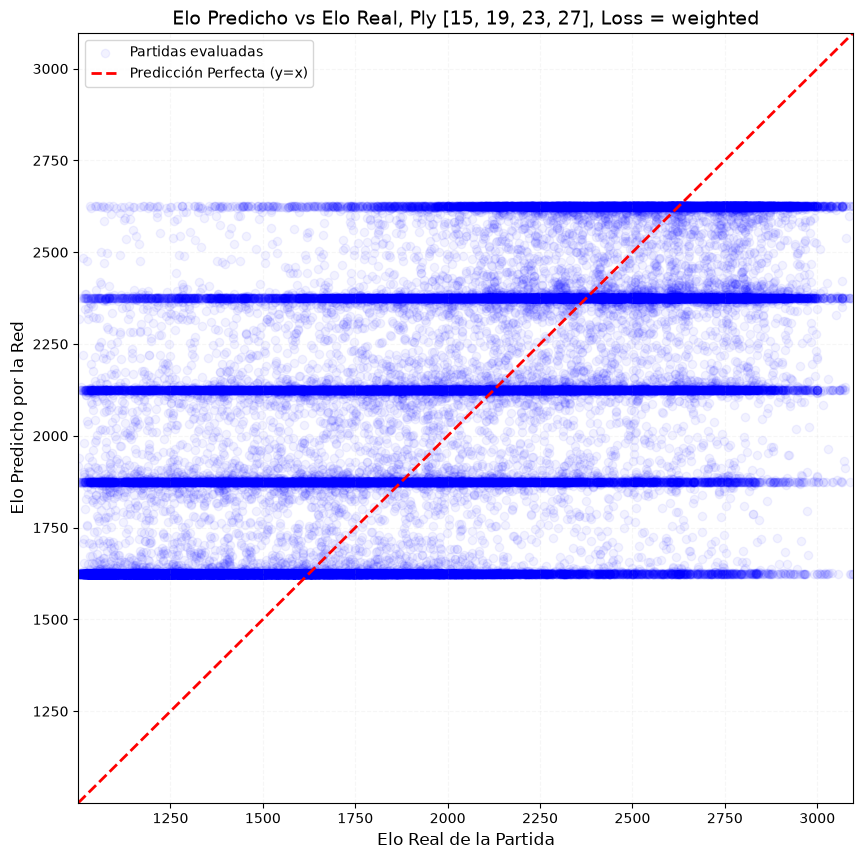

In [187]:
plt.figure(figsize=(10, 10))

plt.scatter(y_raw_test, regresion, alpha=0.05, color='blue', label='Partidas evaluadas')

min_val = min(min(y_raw_test), min(regresion))
max_val = max(max(y_raw_test), max(regresion))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta (y=x)')

plt.title(f'Elo Predicho vs Elo Real, Ply {ply}, Loss = {crit}', fontsize=14)
plt.xlabel('Elo Real de la Partida', fontsize=12)
plt.ylabel('Elo Predicho por la Red', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.1)
plt.legend()

# Limitar los ejes a valores lógicos del ajedrez (ej. 800 a 3000)
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.show()

### Convertir el regresor en un "clasificador"

In [ ]:
ruta_archivo = f"../data/predict/salida_para_clasificador.npy"  # Ajusta según tu estructura
datos = np.load(ruta_archivo)
y_pred_regresor = np.clip((datos - 1000) // divisor, 0, num_clases).astype(int)


7
7


In [29]:
acc_exacto = accuracy_score(y_true_clases, y_pred_regresor)

# Precisión con margen (Acierto si le erró por 1 categoría o menos)
distancia = np.abs(y_true_clases - y_pred_regresor)
acc_margen_1 = np.mean(distancia <= 1)

print(f"Accuracy Exacto (mismo bin): {acc_exacto * 100:.2f}%")
print(f"Accuracy con margen de ±1 bin (±{divisor} Elo): {acc_margen_1 * 100:.2f}%")



Accuracy Exacto (mismo bin): 25.13%
Accuracy con margen de ±1 bin (±250 Elo): 68.35%


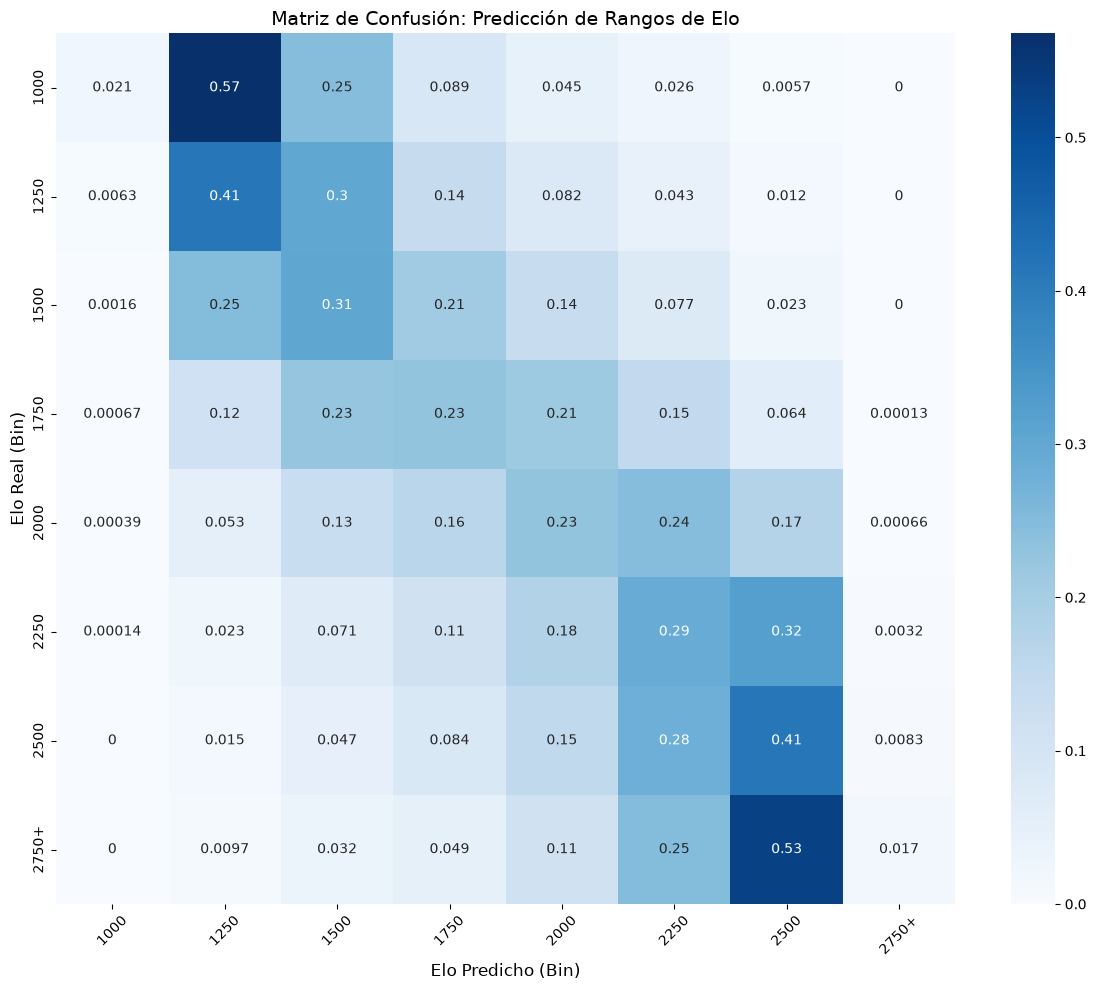

In [31]:
# 1. Generar los nombres de los Bins para los ejes
etiquetas_elo = [f"{1000 + i*divisor}" for i in range(num_clases)]
etiquetas_elo[-1] = f"{1000+(num_clases-1)*divisor}+"
# 2. Calcular la matriz
cm = confusion_matrix(y_true_clases, y_pred_regresor)

# 3. Opcional pero recomendado para tesis: Normalizar la matriz por filas 
# (Muestra porcentajes en lugar de conteos absolutos, útil si las clases están desbalanceadas)
cm_porcentual = confusion_matrix(y_true_clases, y_pred_regresor, normalize='true')

# 4. Dibujar el mapa de calor (Heatmap)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_porcentual, 
            annot=True,
            cmap="Blues", 
            xticklabels=etiquetas_elo, 
            yticklabels=etiquetas_elo)

plt.xlabel("Elo Predicho (Bin)", fontsize=12)
plt.ylabel("Elo Real (Bin)", fontsize=12)
plt.title("Matriz de Confusión: Predicción de Rangos de Elo", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()